# CATS AND DOGS

In the proccess of this project we will discuss the quality of various Neural Network models to analyse and Classify a Dataset of 37 types of cat and dog races. This short study will be done using a Dataset provided by Oxford University called : Oxford-IIIT Pet Dataset. 

The project is divided in 5 different steps :

- Exploration of the Dataset
- Binary Classification between cats and dogs
- Classification between 37 cat and dog races
- Animal Segmentation
- Comparative Analyses

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Introduction : étude de l'ensemble des données
<p>Images de chats et de chiens issues du jeu de données <i>OxfordIIITPet</i></p>
<p>Categories binaires : Chat / Chien</p>
<p>Classes : 37 races de chats et de chiens</p>

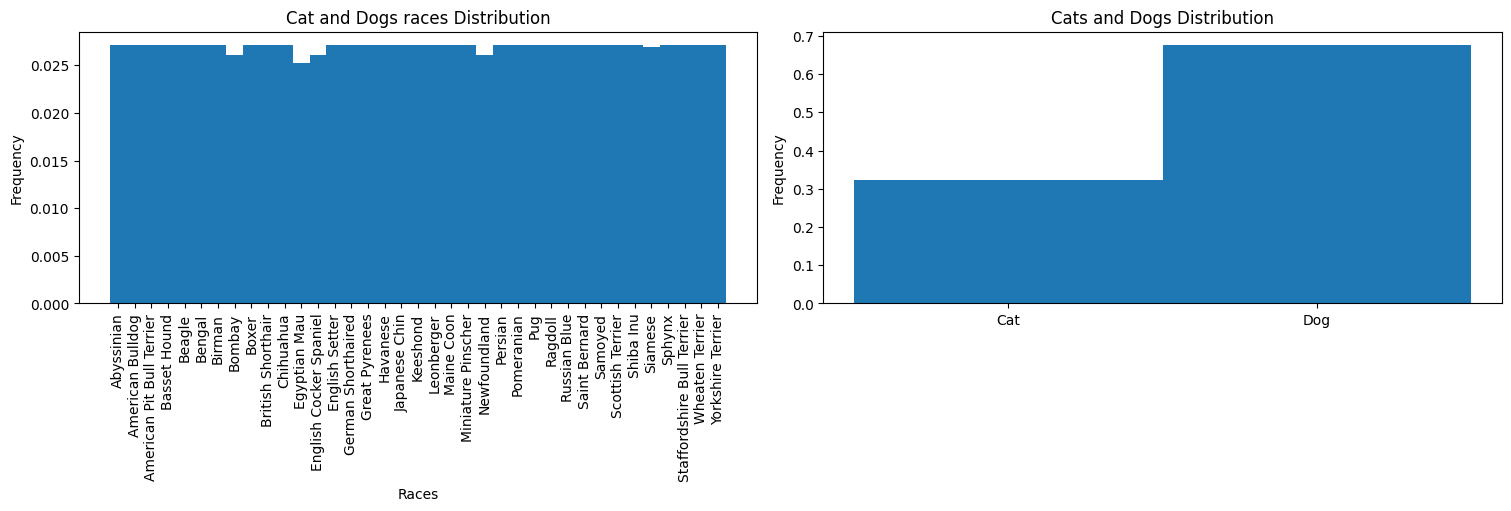

In [3]:
datapath = '../data/data_cats_and_dogs'
transform = torchvision.transforms.ToTensor()
dataset = torchvision.datasets.OxfordIIITPet(root=datapath, target_types="binary-category", download=True, transform=transform)

def get_data_statistics(dataset):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), layout="constrained")

    axes[0].hist(dataset._labels, bins=np.arange(38)-0.5, density=True)
    axes[0].set_title('Cat and Dogs races Distribution')
    axes[0].set_xlabel('Races')
    axes[0].set_xticks(np.arange(37))
    axes[0].set_xticklabels(list(dataset.classes))
    axes[0].set_ylabel('Frequency')
    axes[0].tick_params(axis='x', rotation=90)
    
    axes[1].hist(dataset._bin_labels, bins=np.arange(3)-0.5, density=True)
    axes[1].set_title('Cats and Dogs Distribution')
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(list(dataset.bin_classes))
    axes[1].set_ylabel('Frequency')
    plt.show()

get_data_statistics(dataset)

Il y a nettement plus d'images de chiens que de chats</p>
Les 37 races sont globalement équilibrées

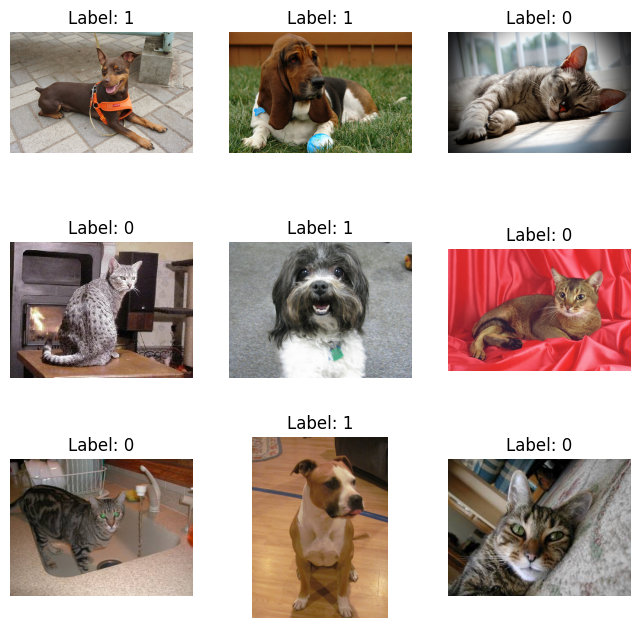

In [3]:
# Plot 9 random images from the MNIST train dataset
def plot_images(img_dataset, RGB='True'):
    """Plots 9 random images from the given dataset

    Args:
        img_dataset (torch.utils.data.Dataset): The dataset to plot images from
    """
    # Set up a 3x3 grid for plotting 9 random images
    figure = plt.figure(figsize=(8, 8))
    cols, rows = 3, 3
    
    # Plot 9 random images from the img_dataset
    for i in range(1, cols * rows + 1):
        random_idx = torch.randint(len(img_dataset), size=(1,)).item()  # Pick a random index
        img, label = img_dataset[random_idx]  # Get the image and its label
        figure.add_subplot(rows, cols, i)  # Add subplot
        plt.title(f'Label: {label}')  # Set title to show the label
        plt.axis("off")  # Turn off axis
        if RGB == 'True':
            plt.imshow(torch.permute(img.squeeze(),(1,2,0)))  # Plot image
        else:
            plt.imshow(img.squeeze())  # Plot image
    
    plt.show()  # Display the figure

plot_images(dataset)

Biais visuels possibles :</p>
Animaux parfois entiers, parfois coupés, luminosité parfois mauvaise, la résolution est bonne mais nous devrons probablement la dégrader pour pouvoir entrainer un CNN. La taille des images devra être modifiée pour qu'elles aient toutes les mêmes dimensions

In [3]:
dataset

Dataset OxfordIIITPet
    Number of datapoints: 3680
    Root location: ../data/data_cats_and_dogs
    StandardTransform
Transform: ToTensor()

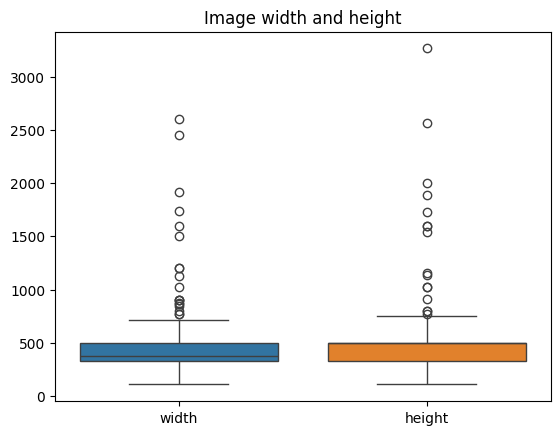

In [4]:
# ANALYSE OF THE IMAGES SIZES

img_sizes = []
for i in range(3680):
    img, _ = dataset[i]
    img_sizes.append([np.shape(img)[1], np.shape(img)[2]])

import seaborn as sns
plt.figure()
ax = sns.boxplot(np.array(img_sizes))
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(['width', 'height'])
plt.title("Image width and height")
plt.show()

In [25]:
print(f'mean width: {int(np.mean(img_sizes))}, mean height: {int(np.mean(img_sizes))}')

mean width: 407, mean height: 407


The mean value may be to high to train the model efficiently, it will probably be choosen lower than 407 at the end to train the model

In [4]:
## FONCTION D'IMPORTATION DES DONNEES choix de la taille des images, de la taille du batch et de la catégorie (espèce, race ou segmentation)

def get_datasets_loaders(batch_size, target_types:str="binary-category", size=(100, 100), norm_like_ImageNet=False):
    """_gets datasets and dataloaders for the OxfordIIIPet dataset depending on the targeted labels or segmentation_

    Args:
        batch_size (int): batch size
        target_types (str): _
            "binary-category" : cats / dogs, 
            "category" : cats and dogs races, 
            "segmentation" : PIL image segmentation trimap of the images
        resize (bool): resize the images
        size (tuple): resize the images with this size_.
    """
    transform = torchvision.transforms.Compose([torchvision.transforms.Resize(size),
                                                    torchvision.transforms.ToTensor()])
    # pour normaliser les images comme ImageNet
    if norm_like_ImageNet == True:
        transform = torchvision.transforms.Compose([torchvision.transforms.Resize(size),
                                                    torchvision.transforms.ToTensor(),
                                                    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]) # recommended for VGG16 or ResNet18 cf Doc
    # chargement des datasets
    if target_types != 'segmentation':
        train_dataset = datasets.OxfordIIITPet(root=datapath, split="trainval", target_types=target_types, transform=transform, download=True) #transform=transform,
        test_dataset = datasets.OxfordIIITPet(root=datapath, split="test", target_types=target_types, transform=transform, download=True) #transform=transform

    elif target_types == 'segmentation':
        # fonction pour transformer les masques en tenseurs composés de valeurs entières 0, 1, 2 (animal, fond, contour)
        def mask_transform(mask):

            mask = mask.resize(size, Image.NEAREST)
            mask_np = np.array(mask)
            # Si les valeurs sont dans [0, 1], on les remet sur 0, 1, 2
            uniques = np.unique(mask_np)
            # Mappe les valeurs uniques à 0, 1, 2
            mask_int = np.searchsorted(uniques, mask_np)
            return torch.from_numpy(mask_int).long()

        target_transform = mask_transform

        train_dataset = datasets.OxfordIIITPet(root=datapath, split="trainval", target_types=target_types, transform=transform, target_transform=target_transform, download=True) #transform=transform,
        test_dataset = datasets.OxfordIIITPet(root=datapath, split="test", target_types=target_types, transform=transform, target_transform=target_transform, download=True) #transform=transform

    train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

    return train_dataset, test_dataset, train_loader, test_loader

<p>IMPORTANT NOTE : the transform argument enables to influence the entry (the image to recognize), it transforms it into a tensor, when the resize argument is True, before converting the image into a tensor, the torchvision function Resize() is applied to the image, so this function is composed with the torchvision function <b>ToTensor()</b>. Removing the composition and keeping only the <b>Resize()</b> function will return a dataset with PIL.Images as entries. The choice of the "target_types" enables to choose between a binary category classification (cats and dogs), a race classification or a segmentation. However using keys such as 'classes' or 'bin_classes' unables to access the different classifications even if one was choosen as a target_types.</p>

## Part 1 : Classification binaire
#### Transfer-learning de ResNet18
<p> ResNet18 est connu comme étant un excellent modèle de classification, on suppose donc que sa base convolutive entrainée sur ImageNet a déjà acquis de très bonnes features extraites des images. L'objectif ici est d'utiliser ces features et de modeler la tête classifiante selon le nombre de catégories  que l'on souhaite avoir en sortie du modèle.</p>

<p>Nous avons commencé par entrainer VGG16 mais les résultats obtenus étant mitigés nous avons plutôt continué avec ResNet18</p>

In [ ]:
# GENERAL FUNCTION TO TRAIN A MODEL

def train_model(model, dataloaders, dataset_sizes, criterion, optimizer, scheduler, path, num_epochs=10):
    """ function to train a model
        Author: from a blog post of Sasank Chilamkurthy
        License: BSD, Revised

    Args:
        model : the model to train
        dataloaders : dictionary containing the training and validation dataloaders
        dataset_sizes : dictionary containing the sizes of the training and validation datasets
        criterion : loss function
        optimizer : depends on the model and the training task
        scheduler : enables to adjust the learning rate during training
        path : path to save the best model parameters
        num_epochs : number of epochs. Defaults to 25.

    Returns:
        trained model
    """
    since = time.time()

    saved_losses = {'train': [], 'val': []}
    
    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        path_model = path

        torch.save(model.state_dict(), path_model)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                saved_losses[phase].append(epoch_loss)
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), path_model)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(path_model, weights_only=True))
    return model, saved_losses

In [99]:
num_classes = 2 # binary classification cats / dogs
class_names = dataset.bin_classes

batch_size = 60
num_epochs = 10 
learning_rate = 0.001

img_width, img_height = 224, 224 # recommandé
size = (img_width, img_height)

train_dataset, test_dataset, train_loader, test_loader = get_datasets_loaders(batch_size, target_types="binary-category", size=size, norm_like_ImageNet=True)
dataloaders = {'train': train_loader, 'val': test_loader}
dataset_sizes = {'train' : len(train_dataset) , 'val': len(test_dataset)}

In [100]:
# TRANSFERT LEARNING WITH RESNET18
## Optimisation de tous les paramètres du modèle en partant du modèle pré-entrainé sur ImageNet

model_ft = models.resnet18(weights='IMAGENET1K_V1')  # pré-entrainé sur ImageNet
num_ftrs = model_ft.fc.in_features

model_ft.fc = nn.Linear(num_ftrs, num_classes) # modification de la dernière couche du modèle pour l'adaper au nombre de classes

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss() # reduction='mean' (cf TP xai.ipynb)

# Ici on optimise tous les paramètres du modèle
# Tester et comparer avec l'optimisation des paramètres uniquement de la tête classifiante
optimizer_ft = optim.SGD(model_ft.parameters(), lr=learning_rate, momentum=0.9)

# Le learning rate est divisé par 10 au bout de chaque période de 7 epochs, cela affine l'apprentissage au fur et à mesure
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [ ]:
model_ft, saved_losses = train_model(model_ft, dataloaders, 
                                     dataset_sizes, 
                                     criterion, 
                                     optimizer_ft, 
                                     exp_lr_scheduler,
                                     path = 'restnet_ft_binary.pt',
                                     num_epochs=num_epochs)

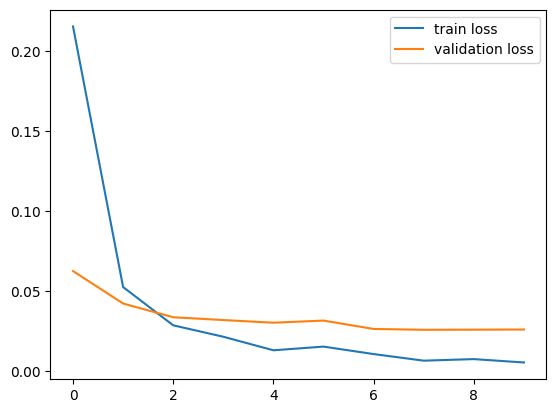

In [24]:
plt.plot(saved_losses['train'],label='train loss')
plt.plot(saved_losses['val'],label='validation loss')
plt.legend()
plt.show()

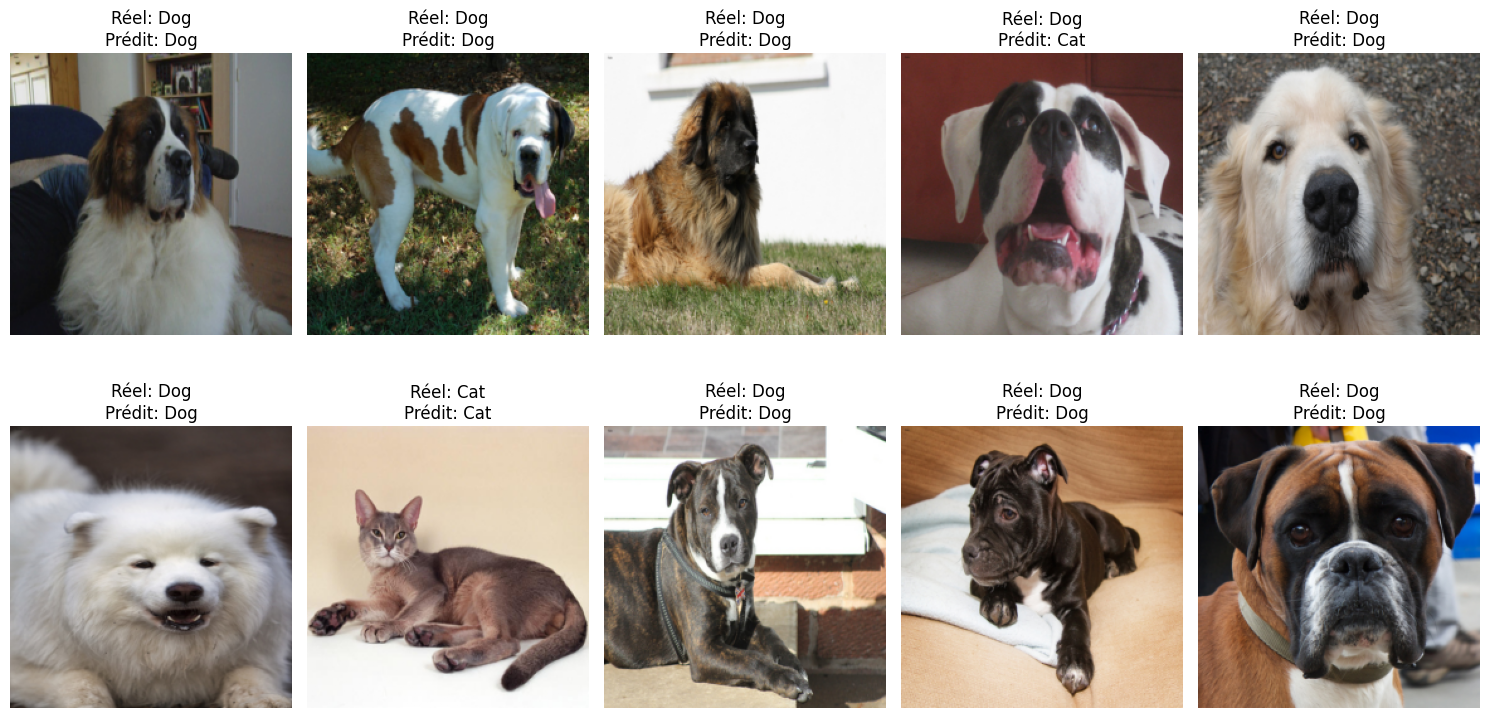

In [50]:
def plot_val_images(model, test_loader, class_names, device, n_images=10):
    """
    Affiche n_images du test_loader avec labels réels et labels prédits.
    """
    model.eval()
    idxs = np.random.choice(len(test_dataset), n_images, replace=False)
    images, labels, preds = [], [], []
    for i in range(n_images):
        idx = idxs[i]
        image, label = test_dataset[idx]
        image = image.to(device).unsqueeze(0)
        with torch.no_grad():
            output = model(image)
            _, pred = torch.max(output, 1)
        images.append(image.squeeze(0).cpu())
        labels.append(label)
        preds.append(pred.item())

    plt.figure(figsize=(15, 8))
    for i, idx in enumerate(idxs):
        ax = plt.subplot(2, n_images//2, i+1)
        img = images[i].permute(1,2,0).numpy()
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(f"Réel: {class_names[labels[i]]}\nPrédit: {class_names[preds[i]]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_val_images(model_ft, test_loader, dataset.bin_classes, device, n_images=10)

### Part 2 : Classification - Fine-tuning de ResNet réutilisé
License BSD Code adapté du tuto Torch de transfer learning

In [14]:
num_classes = 37 # classification par races
class_names = dataset.classes

batch_size = 60
num_epochs = 10 
learning_rate = 0.001

img_width, img_height = 224, 224 # recommandé pour VGG16, taille de IMAGENET dataset ayant entrainé vgg16
size = (img_width, img_height)

train_dataset, test_dataset, train_loader, test_loader = get_datasets_loaders(batch_size, target_types="category", size=size, norm_like_ImageNet=False)
dataloaders = {'train': train_loader, 'val': test_loader}
dataset_sizes = {'train' : len(train_dataset) , 'val': len(test_dataset)}

In [ ]:
# TRANSFERT LEARNING WITH RESNET18
## Optimisation de tous les paramètres du modèle en partant du modèle pré-entrainé sur ImageNet

model_ft2 = models.resnet18(weights='IMAGENET1K_V1')  # pré-entrainé sur ImageNet
num_ftrs = model_ft2.fc.in_features

model_ft2.fc = nn.Linear(num_ftrs, num_classes) # modification de la dernière couche du modèle pour l'adaper au nombre de classes

model_ft2 = model_ft2.to(device)

criterion = nn.CrossEntropyLoss()

# Ici on optimise tous les paramètres du modèle
# Tester et comparer avec l'optimisation des paramètres uniquement de la tête classifiante
optimizer_ft = optim.SGD(model_ft2.parameters(), lr=learning_rate, momentum=0.9)

# Le learning rate est divisé par 10 au bout de chaque période de 7 epochs, cela affine l'apprentissage au fur et à mesure
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [ ]:
model_ft2 = train_model(model_ft2, 
                        dataloaders, 
                        dataset_sizes, 
                        criterion, 
                        optimizer_ft, 
                        exp_lr_scheduler,
                        path='model_ft_calsses.pt',
                        num_epochs=num_epochs)

Epoch 0/9
----------
train Loss: 2.9074 Acc: 0.3399
val Loss: 1.8186 Acc: 0.7018

Epoch 1/9
----------
train Loss: 1.3623 Acc: 0.8043
val Loss: 1.0083 Acc: 0.8332

Epoch 2/9
----------
train Loss: 0.7929 Acc: 0.8886
val Loss: 0.7544 Acc: 0.8596

Epoch 3/9
----------
train Loss: 0.5485 Acc: 0.9234
val Loss: 0.6062 Acc: 0.8733

Epoch 4/9
----------
train Loss: 0.4146 Acc: 0.9380
val Loss: 0.5407 Acc: 0.8765

Epoch 5/9
----------
train Loss: 0.3299 Acc: 0.9533
val Loss: 0.4834 Acc: 0.8855

Epoch 6/9
----------
train Loss: 0.2666 Acc: 0.9655
val Loss: 0.4579 Acc: 0.8883

Epoch 7/9
----------
train Loss: 0.2308 Acc: 0.9739
val Loss: 0.4522 Acc: 0.8893

Epoch 8/9
----------
train Loss: 0.2243 Acc: 0.9758
val Loss: 0.4509 Acc: 0.8872

Epoch 9/9
----------
train Loss: 0.2205 Acc: 0.9772
val Loss: 0.4482 Acc: 0.8888

Training complete in 5m 59s
Best val Acc: 0.889343


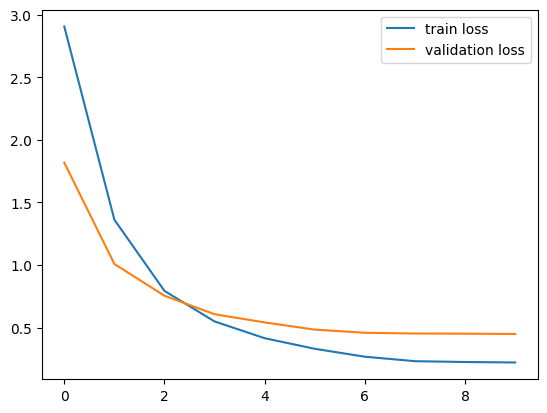

In [10]:
plt.plot(saved_losses['train'],label='train loss')
plt.plot(saved_losses['val'],label='validation loss')
plt.legend()
plt.show()

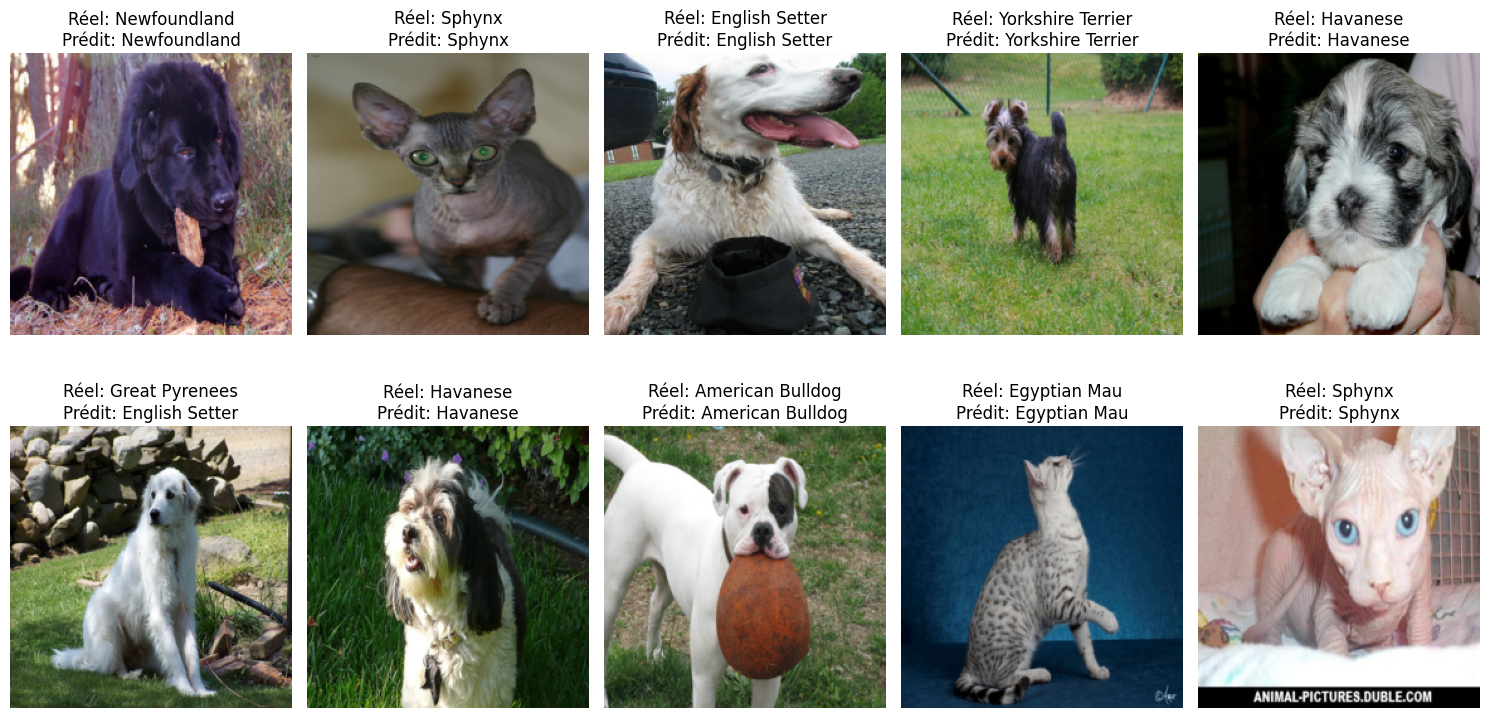

In [19]:
plot_val_images(model_ft2, test_loader, dataset.classes, device, n_images=10)

In [ ]:
# fonction pour calculer les performances du modèles selon les races de chats et de chiens

def evaualte_model_by_classes(model, test_loader, class_names, device):
    model.eval()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    
    from sklearn.metrics import classification_report
    print(classification_report(all_labels, all_preds, target_names=class_names))

evaualte_model_by_classes(model_ft2, test_loader, dataset.classes, device)

                            precision    recall  f1-score   support

                Abyssinian       0.88      0.86      0.87        98
          American Bulldog       0.74      0.87      0.80       100
 American Pit Bull Terrier       0.70      0.53      0.60       100
              Basset Hound       0.94      0.88      0.91       100
                    Beagle       0.82      0.94      0.88       100
                    Bengal       0.79      0.93      0.85       100
                    Birman       0.74      0.85      0.79       100
                    Bombay       0.89      0.97      0.92        88
                     Boxer       0.80      0.88      0.84        99
         British Shorthair       0.92      0.78      0.84       100
                 Chihuahua       0.85      0.85      0.85       100
              Egyptian Mau       0.93      0.87      0.90        97
    English Cocker Spaniel       0.94      0.89      0.91       100
            English Setter       0.88      0.92

### Part 3: U-net from scratch pour Segmenter nos images

source : https://debuggercafe.com/unet-from-scratch-using-pytorch/

In [11]:
batch_size = 16
size = (64, 64)  # taille des images redimensionnées

train_dataset, test_dataset, train_loader, test_loader = get_datasets_loaders(batch_size, target_types="segmentation", size=size, norm_like_ImageNet=False)
dataloaders = {'train': train_loader, 'val': test_loader}
dataset_sizes = {'train' : len(train_dataset) , 'val': len(test_dataset)}

In [12]:
def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
    )

class UNetSmall(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.down1 = double_conv(3, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = double_conv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = double_conv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = double_conv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv3 = double_conv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = double_conv(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv1 = double_conv(64, 32)

        self.out = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)
        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        bn = self.bottleneck(p3)

        u3 = self.up3(bn)
        c3 = self.conv3(torch.cat([u3, d3], dim=1))
        u2 = self.up2(c3)
        c2 = self.conv2(torch.cat([u2, d2], dim=1))
        u1 = self.up1(c2)
        c1 = self.conv1(torch.cat([u1, d1], dim=1))

        out = self.out(c1)
        return out

In [13]:
def train_unet(model, dataloaders, dataset_sizes, optimizer, criterion, path, num_epochs=10, device='cuda'):

    model.to(device)
    train_losses, val_losses = [], []
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            running_loss = 0.0

            with torch.set_grad_enabled(phase == 'train'):
                for imgs, masks in dataloaders[phase]:
                    imgs = imgs.to(device)
                    masks = masks.to(device)
                    if masks.ndim == 4 and masks.shape[1] == 1:
                        masks = masks.squeeze(1)
                    if phase == 'train':
                        optimizer.zero_grad()
                    outputs = model(imgs)
                    loss = criterion(outputs, masks.long())
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                    running_loss += loss.item() * imgs.size(0)
            epoch_loss = running_loss / dataset_sizes[phase]
            if phase == 'train':
                train_losses.append(epoch_loss)
            else:
                val_losses.append(epoch_loss)
            print(f"{phase} Loss: {epoch_loss:.4f}")
            
    # Plot des pertes
    plt.plot(train_losses, label='train loss')
    plt.plot(val_losses, label='val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    path_model = path
    torch.save(model.state_dict(), path_model)
    return model, train_losses, val_losses

In [14]:
def plot_segmentation_results(model, dataset, device='cuda', num_images=5):
    model.eval()
    fig, axes = plt.subplots(num_images, 3, figsize=(9, 3 * num_images))
    for i in range(num_images):
        img, mask = dataset[i]
        img_input = img.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(img_input)
            pred_mask = torch.argmax(output.squeeze(0), dim=0).cpu()
        axes[i, 0].imshow(torch.permute(img, (1, 2, 0)))
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(mask.squeeze(), cmap="tab10")
        axes[i, 1].set_title("Masque réel")
        axes[i, 1].axis("off")
        axes[i, 2].imshow(pred_mask, cmap="tab10")
        axes[i, 2].set_title("Prédiction")
        axes[i, 2].axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
# Initialisation du modèle, optimizer et loss
num_classes = 3  # fond, contour, animal
model = UNetSmall(num_classes=num_classes)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
num_epochs = 20

# Entraînement du modèle
model, train_losses, val_losses = train_unet(
    model,
    dataloaders,
    dataset_sizes,
    optimizer,
    criterion,
    num_epochs=num_epochs,
    device=device
 )

# Visualisation sur l'ensemble de validation
plot_segmentation_results(model, dataloaders['val'].dataset, device=device, num_images=5)

In [ ]:
# ancienne fonction pour train le unet
def train_unet(model, dataloaders, dataset_sizes, criterion, optimizer, num_epochs=10):
    """ function to train a model
        Author: from a blog post of Sasank Chilamkurthy
        License: BSD, Revised

    Args:
        model : the model to train
        dataloaders : dictionary containing the training and validation dataloaders
        dataset_sizes : dictionary containing the sizes of the training and validation datasets
        criterion : loss function
        optimizer : depends on the model and the training task
        num_epochs : number of epochs. Defaults to 25.

    Returns:
        trained model, saved_losses
    """
    since = time.time()

    saved_losses = {'train': [], 'val': []}
    
    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        path = 'unet_model.pt'

        torch.save(model.state_dict(), path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, segm in dataloaders[phase]:
                    inputs = inputs.to(device)
                    segm = segm.to(device)
                    segm_onehot = labels_to_onehot(segm)
                    

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        outputs = outputs.to(device)
                        #print(outputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, segm_onehot)
                        

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == segm.data)

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                saved_losses[phase].append(epoch_loss)
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(path, weights_only=True))
    return model, saved_losses